# 04 — Method 5: Flood Stress-Test Sensitivity Analysis

Notebook ini memisahkan **Metode 5** dari model training utama.

**Pertanyaan utama:**

> Jika actor-region unit diberi tekanan biaya akibat skenario banjir, unit mana yang tidak punya buffer finansial dan paling cepat collapse?

Notebook ini **bukan supervised modelling** karena dataset tidak memiliki label observasi seperti actual stockout, actual flood damage, atau actual delivery delay.  
Notebook ini adalah **scenario-based sensitivity analysis**.

## Domain basis

Keputusan metodologis yang dipakai:

| Keputusan | Dasar domain |
|---|---|
| Stress test dipakai sebagai analisis ketahanan | Supply chain resilience melihat kemampuan rantai pasok untuk persist, adapt, atau transform saat terjadi perubahan/disruption. |
| Unit dianggap survive jika revenue masih menutup cost | Prinsip break-even / financial feasibility: unit tidak collapse secara finansial selama revenue > cost. |
| Buffer dihitung dari margin terhadap cost/revenue | Margin menunjukkan ruang tahan sebelum unit menyentuh break-even. |
| Scenario shock adalah grid sensitivitas, bukan estimasi kausal | Tidak ada data observasi dampak banjir terhadap biaya/revenue, jadi shock ditulis sebagai scenario stress. |

## References used in the methodological notes

- Ponomarov, S. Y., & Holcomb, M. C. (2009). *Understanding the concept of supply chain resilience*. The International Journal of Logistics Management.
- Wieland, A., & Durach, C. F. (2021). *Two perspectives on supply chain resilience*. Journal of Business Logistics.
- Simchi-Levi, D., Wang, H., & Wei, Y. (2018). *Increasing supply chain robustness through process flexibility and inventory*. Production and Operations Management.
- Boardman, A. E., Greenberg, D. H., Vining, A. R., & Weimer, D. L. (2018). *Cost-Benefit Analysis: Concepts and Practice*.

In [26]:
from pathlib import Path
import json, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
for p in [OUTPUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'legend.frameon': False
})
COLORS = {
    'blue': '#2F80ED',
    'navy': '#243B53',
    'orange': '#F2994A',
    'red': '#D64545',
    'green': '#27AE60',
    'purple': '#7B61FF',
    'gray': '#6B7280',
    'teal': '#2D9CDB'
}
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)

def safe_div(a, b):
    return pd.to_numeric(a, errors='coerce') / pd.to_numeric(b, errors='coerce').replace(0, np.nan)

def mode_or_unknown(s):
    s = s.dropna()
    if s.empty:
        return 'Unknown'
    return s.value_counts().idxmax()

## 1. Load transition outputs from Notebook 03

In [27]:
required = [
    '03_rice_full_predictions.csv',
    '03_actor_region_model_summary.csv',
    '03_flood_full_predictions.csv'
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Jalankan Notebook 03 dulu. Missing: {missing}')

rice = pd.read_csv(OUTPUT_DIR / '03_rice_full_predictions.csv')
actor_region = pd.read_csv(OUTPUT_DIR / '03_actor_region_model_summary.csv')
flood = pd.read_csv(OUTPUT_DIR / '03_flood_full_predictions.csv')

def normalize_region_key(x):
    x = str(x).upper().strip()
    x = x.replace('KABUPATEN ', '').replace('KOTA ', '')
    return ' '.join(x.split())

# Flexible revenue column naming.
if 'output_value' in rice.columns:
    rice['base_revenue'] = pd.to_numeric(rice['output_value'], errors='coerce')
elif 'revenue' in rice.columns:
    rice['base_revenue'] = pd.to_numeric(rice['revenue'], errors='coerce')
else:
    raise ValueError('Rice transition file must contain output_value or revenue.')

rice['base_cost'] = pd.to_numeric(rice['total_cost'], errors='coerce')
rice['base_margin'] = pd.to_numeric(rice['margin'], errors='coerce')
rice['base_cost_revenue_ratio'] = safe_div(rice['base_cost'], rice['base_revenue'])
rice['region_key'] = rice['region'].map(normalize_region_key)
actor_region['region_key'] = actor_region['region'].map(normalize_region_key)

print('Rice full predictions:', rice.shape)
print('Actor-region summary:', actor_region.shape)
print('Flood predictions:', flood.shape)
display(rice.head(3))
display(actor_region.head(3))

# Optional Open Data Jabar regional flood exposure bridge from Notebook 01.
# Merge uses region_key to avoid uppercase/title-case mismatch.
external_path = OUTPUT_DIR / '01b_jabar_flood_exposure_by_region.csv'
if external_path.exists():
    jabar_exposure = pd.read_csv(external_path)
    if 'region_key' not in jabar_exposure.columns:
        jabar_exposure['region_key'] = jabar_exposure['region'].map(normalize_region_key)
    keep = [c for c in [
        'region_key', 'historical_flood_exposure_score', 'historical_flood_exposure_level',
        'flood_events_total', 'flood_events_recent_5y', 'external_data_coverage', 'source_file_used'
    ] if c in jabar_exposure.columns]
    jabar_exposure = jabar_exposure[keep].drop_duplicates('region_key').copy()
else:
    jabar_exposure = pd.DataFrame({
        'region_key': rice['region_key'].dropna().unique(),
        'historical_flood_exposure_score': 0.0,
        'historical_flood_exposure_level': 'Low',
        'external_data_coverage': 'missing'
    })

context_cols = [c for c in jabar_exposure.columns if c != 'region_key']
rice = rice.drop(columns=[c for c in context_cols if c in rice.columns], errors='ignore')
rice = rice.merge(jabar_exposure, on='region_key', how='left')
rice['historical_flood_exposure_score'] = pd.to_numeric(rice.get('historical_flood_exposure_score', 0), errors='coerce').fillna(0).clip(0, 1)
rice['historical_flood_exposure_level'] = rice.get('historical_flood_exposure_level', pd.Series(index=rice.index)).fillna('Low')
rice['external_data_coverage'] = rice.get('external_data_coverage', pd.Series(index=rice.index)).fillna('missing')

external_match_rate = rice['historical_flood_exposure_score'].notna().mean()
print('External regional flood exposure merged into stress-test input.')
print('Max exposure score:', rice['historical_flood_exposure_score'].max())
print('Region-key coverage:', rice[['region', 'region_key', 'historical_flood_exposure_score']].drop_duplicates().sort_values('region_key').to_string(index=False))

Rice full predictions: (787, 34)
Actor-region summary: (24, 25)
Flood predictions: (50000, 30)


,actor,region,region_key,dmu,vulnerability_label,label_reason,total_cost,output_value,margin,cost_revenue_ratio,operational_burden_ratio,margin_ratio,operational_cost,quantity_proxy,precipitation_quality_pct,total_precipitation_pct,final_vulnerability_score,flood_events_total,flood_events_mean_annual,flood_events_recent_5y,flood_events_max_yearly,flood_events_trend_slope,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,source_file_used,predicted_vulnerability_label,predicted_proba_high_vulnerability,predicted_proba_low_vulnerability,predicted_proba_medium_vulnerability,base_revenue,base_cost,base_margin,base_cost_revenue_ratio
0,Farmer,Garut,GARUT,1,Low Vulnerability,Far from actor frontier,11418000.0,16200000.0,4782000.0,0.704815,0.417901,0.295185,6770000.0,2800.0,NaN,NaN,0.287454,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv,Low Vulnerability,0.003007,0.996993,0.000000,16200000.0,11418000.0,4782000.0,0.704815
1,Farmer,Garut,GARUT,2,High Vulnerability,R/C < 1: below break-even; Negative margin; Fa...,8264000.0,8100000.0,-164000.0,1.020247,0.733333,-0.020247,5940000.0,1400.0,NaN,NaN,0.847148,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv,High Vulnerability,0.988324,0.003232,0.008445,8100000.0,8264000.0,-164000.0,1.020247
2,Farmer,Garut,GARUT,3,Low Vulnerability,Far from actor frontier,6450000.0,14850000.0,8400000.0,0.434343,0.228283,0.565657,3390000.0,2000.0,NaN,NaN,0.256153,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv,Low Vulnerability,0.001843,0.990935,0.007222,14850000.0,6450000.0,8400000.0,0.434343


,region,actor,n_units,median_total_cost,median_revenue,median_margin,median_cost_revenue_ratio,median_operational_burden_ratio,median_margin_ratio,median_vulnerability_score,dominant_true_vulnerability_label,dominant_predicted_vulnerability_label,predicted_high_vulnerability_share,true_high_vulnerability_share,median_predicted_proba_high,region_key,flood_events_total,flood_events_mean_annual,flood_events_recent_5y,flood_events_max_yearly,flood_events_trend_slope,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,source_file_used
0,Garut,Farmer,98,7641100.0,13570000.0,6111000.0,0.417240,0.224878,0.582760,0.251364,Low Vulnerability,Low Vulnerability,0.204082,0.214286,0.003007,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv
1,Garut,Middlemen,24,40650000.0,26840000.0,-6500000.0,1.357774,0.278229,-0.357774,0.705973,High Vulnerability,High Vulnerability,0.916667,0.916667,0.997186,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv
2,Garut,Retail,23,5750000.0,3500000.0,-2600000.0,1.742857,1.000000,-0.742857,0.763876,High Vulnerability,High Vulnerability,0.913043,0.913043,1.000000,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv


External regional flood exposure merged into stress-test input.
Max exposure score: 1.0
Region-key coverage:      region  region_key  historical_flood_exposure_score
      Garut       GARUT                         0.394955
  Indramayu   INDRAMAYU                         0.055935
   Karawang    KARAWANG                         1.000000
     Subang      SUBANG                         0.364147
Tasikmalaya TASIKMALAYA                         0.006557


## External bridge policy for Method 5

Open Data Jabar historical flood-event counts are used only as a **regional stress modifier**.

The modifier is intentionally capped:

```text
effective_cost_shock_pct = base_cost_shock_pct × (1 + 0.10 × historical_flood_exposure_score)
```

This means external flood history can increase the stress grid by at most 10%, so it enriches regional context without dominating the primary Flood Prediction dataset.

## 2. Define stress scenarios

Scenario shock di sini adalah **sensitivity grid**, bukan klaim bahwa banjir pasti menaikkan biaya sebesar angka tertentu.

Agar keputusan tidak terlihat arbitrary, analisis dibagi menjadi dua:

1. **Data-derived buffer**  
   Mengukur berapa persen kenaikan cost atau penurunan revenue yang masih bisa ditahan sebelum unit mencapai break-even.

2. **Scenario stress grid**  
   Low / Medium / High dipakai sebagai grid uji sensitivitas. Threshold ini adalah *internal decision thresholds*, bukan angka universal dari paper.

| Scenario | Cost-side stress grid |
|---|---:|
| Low | 5% cost increase |
| Medium | 15% cost increase |
| High | 30% cost increase |

In [28]:
# Flood scenario levels are extracted from the predicted flood distribution.
flood_prob_col = 'predicted_FloodProbability' if 'predicted_FloodProbability' in flood.columns else 'FloodProbability'
scenario_order = ['Low', 'Medium', 'High']

if 'predicted_flood_risk_level' in flood.columns:
    flood_level_col = 'predicted_flood_risk_level'
elif 'flood_risk_label' in flood.columns:
    flood_level_col = 'flood_risk_label'
else:
    q33, q66 = flood[flood_prob_col].quantile([1/3, 2/3])
    flood['predicted_flood_risk_level'] = pd.cut(
        flood[flood_prob_col],
        bins=[-np.inf, q33, q66, np.inf],
        labels=scenario_order
    ).astype(str)
    flood_level_col = 'predicted_flood_risk_level'

flood_scenarios = (
    flood.groupby(flood_level_col, dropna=False)
    .agg(
        n_flood_cases=(flood_prob_col, 'size'),
        flood_probability_reference=(flood_prob_col, 'median'),
        flood_probability_min=(flood_prob_col, 'min'),
        flood_probability_max=(flood_prob_col, 'max')
    )
    .reset_index()
    .rename(columns={flood_level_col: 'flood_scenario'})
)

# Keep canonical Low/Medium/High rows, adding missing rows if needed.
scenario_policy = pd.DataFrame({
    'flood_scenario': scenario_order,
    'cost_shock_pct': [0.05, 0.15, 0.30],
    'scenario_interpretation': [
        'low cost-side stress grid',
        'medium cost-side stress grid',
        'high cost-side stress grid'
    ]
})
flood_scenarios = scenario_policy.merge(flood_scenarios, on='flood_scenario', how='left')
flood_scenarios['flood_probability_reference'] = flood_scenarios['flood_probability_reference'].fillna(
    flood[flood_prob_col].median()
)
flood_scenarios['n_flood_cases'] = flood_scenarios['n_flood_cases'].fillna(0).astype(int)

flood_scenarios.to_csv(OUTPUT_DIR / '04_stress_scenarios.csv', index=False)
display(flood_scenarios)

,flood_scenario,cost_shock_pct,scenario_interpretation,n_flood_cases,flood_probability_reference,flood_probability_min,flood_probability_max
0,Low,0.05,low cost-side stress grid,16667,0.450002,0.285010,0.475001
1,Medium,0.15,medium cost-side stress grid,16666,0.500000,0.475001,0.519999
2,High,0.30,high cost-side stress grid,16667,0.549998,0.519999,0.724990


## 3. Calculate break-even resilience buffer

Core variable Metode 5:

```text
cost_shock_tolerance = (revenue - cost) / cost
```

Interpretasi:

- `0.00` berarti unit sudah di break-even.
- nilai negatif berarti unit sudah rugi / already failed.
- `0.10` berarti unit hanya kuat sampai cost naik sekitar 10% sebelum menyentuh break-even.

Untuk revenue-side buffer:

```text
revenue_drop_tolerance = (revenue - cost) / revenue
```

`combined_break_even_buffer` memakai nilai minimum dari dua buffer agar konservatif.

In [29]:
buffer = rice.copy()
buffer['cost_shock_tolerance'] = safe_div(buffer['base_revenue'] - buffer['base_cost'], buffer['base_cost'])
buffer['revenue_drop_tolerance'] = safe_div(buffer['base_revenue'] - buffer['base_cost'], buffer['base_revenue'])
buffer['combined_break_even_buffer'] = buffer[['cost_shock_tolerance', 'revenue_drop_tolerance']].min(axis=1)

# Label buffer resilience. Thresholds are analytic interpretation thresholds, not universal paper constants.
conditions = [
    buffer['base_margin'].le(0) | buffer['combined_break_even_buffer'].le(0),
    buffer['combined_break_even_buffer'].lt(0.05),
    buffer['combined_break_even_buffer'].lt(0.15),
    buffer['combined_break_even_buffer'].lt(0.30),
]
choices = ['Already Failed', 'Very Fragile', 'Fragile', 'Moderate Buffer']
buffer['break_even_resilience_label'] = np.select(conditions, choices, default='Resilient')

buffer_cols = [
    'actor', 'region', 'region_key', 'dmu',
    'predicted_vulnerability_label',
    'historical_flood_exposure_score', 'historical_flood_exposure_level', 'external_data_coverage',
    'base_cost', 'base_revenue', 'base_margin',
    'base_cost_revenue_ratio',
    'cost_shock_tolerance', 'revenue_drop_tolerance',
    'combined_break_even_buffer',
    'break_even_resilience_label'
]
buffer_cols = [c for c in buffer_cols if c in buffer.columns]
buffer[buffer_cols].to_csv(OUTPUT_DIR / '04_actor_unit_resilience_buffer.csv', index=False)

buffer_summary = (
    buffer.groupby(['region', 'region_key', 'actor'], dropna=False)
    .agg(
        n_units=('actor', 'size'),
        median_base_margin=('base_margin', 'median'),
        median_cost_revenue_ratio=('base_cost_revenue_ratio', 'median'),
        median_cost_shock_tolerance=('cost_shock_tolerance', 'median'),
        median_revenue_drop_tolerance=('revenue_drop_tolerance', 'median'),
        median_combined_buffer=('combined_break_even_buffer', 'median'),
        already_failed_share=('break_even_resilience_label', lambda s: s.eq('Already Failed').mean()),
        fragile_or_worse_share=('break_even_resilience_label', lambda s: s.isin(['Already Failed', 'Very Fragile', 'Fragile']).mean()),
        dominant_resilience_label=('break_even_resilience_label', mode_or_unknown),
        dominant_predicted_vulnerability_label=('predicted_vulnerability_label', mode_or_unknown),
        median_historical_flood_exposure_score=('historical_flood_exposure_score', 'median'),
    )
    .reset_index()
)
buffer_summary.to_csv(OUTPUT_DIR / '04_actor_region_resilience_buffer.csv', index=False)
display(buffer_summary.sort_values(['fragile_or_worse_share', 'median_combined_buffer'], ascending=[False, True]).head(12))

,region,region_key,actor,n_units,median_base_margin,median_cost_revenue_ratio,median_cost_shock_tolerance,median_revenue_drop_tolerance,median_combined_buffer,already_failed_share,fragile_or_worse_share,dominant_resilience_label,dominant_predicted_vulnerability_label,median_historical_flood_exposure_score
7,Indramayu,INDRAMAYU,Retail,16,-3.051000e+06,2.114500,-0.527063,-1.114500,-1.114500,1.000000,1.000000,Already Failed,High Vulnerability,0.055935
12,Karawang,KARAWANG,Retail,16,-3.070000e+06,2.023333,-0.505758,-1.023333,-1.023333,1.000000,1.000000,Already Failed,High Vulnerability,1.000000
22,Tasikmalaya,TASIKMALAYA,Retail,28,-3.053750e+06,2.017917,-0.504416,-1.017917,-1.017917,1.000000,1.000000,Already Failed,High Vulnerability,0.006557
2,Garut,GARUT,Retail,23,-2.600000e+06,1.742857,-0.426230,-0.742857,-0.742857,0.913043,1.000000,Already Failed,High Vulnerability,0.394955
17,Subang,SUBANG,Retail,19,-2.495000e+06,1.733333,-0.423077,-0.733333,-0.733333,0.947368,1.000000,Already Failed,High Vulnerability,0.364147
1,Garut,GARUT,Middlemen,24,-6.500000e+06,1.357774,-0.263500,-0.357774,-0.357774,0.916667,1.000000,Already Failed,High Vulnerability,0.394955
21,Tasikmalaya,TASIKMALAYA,Middlemen,29,-7.685347e+06,1.296086,-0.228446,-0.296086,-0.296086,0.793103,1.000000,Already Failed,High Vulnerability,0.006557
13,Karawang,KARAWANG,Rice Miller,14,-5.688835e+06,1.064403,-0.060399,-0.064403,-0.064403,0.714286,1.000000,Already Failed,High Vulnerability,1.000000
11,Karawang,KARAWANG,Middlemen,14,-1.525000e+06,1.017790,-0.016424,-0.017790,-0.017790,0.500000,1.000000,Already Failed,Medium Vulnerability,1.000000
4,Garut,GARUT,Wholesaler,25,-7.000000e+06,1.079545,-0.073684,-0.079545,-0.079545,0.720000,0.880000,Already Failed,High Vulnerability,0.394955


## 4. Expand actor units under flood stress scenarios

In [30]:
# Cross join units with stress scenarios.
unit_stress = buffer.merge(flood_scenarios[['flood_scenario', 'cost_shock_pct', 'flood_probability_reference']], how='cross')

# Open Data Jabar historical exposure is a low-impact regional modifier.
# It can increase the stress grid by at most 10%, so it enriches context without dominating the primary flood model.
unit_stress['historical_flood_exposure_score'] = pd.to_numeric(unit_stress.get('historical_flood_exposure_score', 0), errors='coerce').fillna(0).clip(0, 1)
unit_stress['regional_exposure_stress_modifier'] = 1 + 0.10 * unit_stress['historical_flood_exposure_score']
unit_stress['effective_cost_shock_pct'] = unit_stress['cost_shock_pct'] * unit_stress['regional_exposure_stress_modifier']

unit_stress['stressed_cost'] = unit_stress['base_cost'] * (1 + unit_stress['effective_cost_shock_pct'])
unit_stress['stressed_revenue'] = unit_stress['base_revenue']
unit_stress['stressed_margin'] = unit_stress['stressed_revenue'] - unit_stress['stressed_cost']
unit_stress['stressed_cost_revenue_ratio'] = safe_div(unit_stress['stressed_cost'], unit_stress['stressed_revenue'])

unit_stress['survive_under_stress'] = unit_stress['stressed_margin'].gt(0)
unit_stress['fails_under_stress'] = ~unit_stress['survive_under_stress']

def stress_label(row):
    if row['base_margin'] <= 0:
        return 'Already Failed'
    if not row['survive_under_stress'] and row['flood_scenario'] == 'High':
        return 'Critical Under High Stress'
    if not row['survive_under_stress']:
        return 'Fails Under Scenario'
    if row['combined_break_even_buffer'] < 0.15:
        return 'Borderline'
    return 'Survives Scenario'

unit_stress['stress_risk_label'] = unit_stress.apply(stress_label, axis=1)

stress_cols = [
    'actor', 'region', 'dmu',
    'predicted_vulnerability_label',
    'break_even_resilience_label',
    'flood_scenario', 'flood_probability_reference', 'cost_shock_pct', 'historical_flood_exposure_score', 'regional_exposure_stress_modifier', 'effective_cost_shock_pct',
    'base_cost', 'base_revenue', 'base_margin',
    'cost_shock_tolerance', 'combined_break_even_buffer',
    'stressed_cost', 'stressed_revenue', 'stressed_margin',
    'stressed_cost_revenue_ratio',
    'survive_under_stress', 'stress_risk_label'
]
stress_cols = [c for c in stress_cols if c in unit_stress.columns]
unit_stress[stress_cols].to_csv(OUTPUT_DIR / '04_unit_stress_test_results.csv', index=False)

display(unit_stress[stress_cols].head())

,actor,region,dmu,predicted_vulnerability_label,break_even_resilience_label,flood_scenario,flood_probability_reference,cost_shock_pct,historical_flood_exposure_score,regional_exposure_stress_modifier,effective_cost_shock_pct,base_cost,base_revenue,base_margin,cost_shock_tolerance,combined_break_even_buffer,stressed_cost,stressed_revenue,stressed_margin,stressed_cost_revenue_ratio,survive_under_stress,stress_risk_label
0,Farmer,Garut,1,Low Vulnerability,Moderate Buffer,Low,0.450002,0.05,0.394955,1.039496,0.051975,11418000.0,16200000.0,4782000.0,0.418812,0.295185,1.201145e+07,16200000.0,4.188552e+06,0.741447,True,Survives Scenario
1,Farmer,Garut,1,Low Vulnerability,Moderate Buffer,Medium,0.500000,0.15,0.394955,1.039496,0.155924,11418000.0,16200000.0,4782000.0,0.418812,0.295185,1.319834e+07,16200000.0,3.001656e+06,0.814713,True,Survives Scenario
2,Farmer,Garut,1,Low Vulnerability,Moderate Buffer,High,0.549998,0.30,0.394955,1.039496,0.311849,11418000.0,16200000.0,4782000.0,0.418812,0.295185,1.497869e+07,16200000.0,1.221312e+06,0.924610,True,Survives Scenario
3,Farmer,Garut,2,High Vulnerability,Already Failed,Low,0.450002,0.05,0.394955,1.039496,0.051975,8264000.0,8100000.0,-164000.0,-0.019845,-0.020247,8.693520e+06,8100000.0,-5.935196e+05,1.073274,False,Already Failed
4,Farmer,Garut,2,High Vulnerability,Already Failed,Medium,0.500000,0.15,0.394955,1.039496,0.155924,8264000.0,8100000.0,-164000.0,-0.019845,-0.020247,9.552559e+06,8100000.0,-1.452559e+06,1.179328,False,Already Failed


## 5. Actor-region stress summary

In [31]:
stress_summary = (
    unit_stress.groupby(['flood_scenario', 'region', 'region_key', 'actor'], dropna=False)
    .agg(
        n_units=('actor', 'size'),
        fail_share=('fails_under_stress', 'mean'),
        survive_share=('survive_under_stress', 'mean'),
        median_stressed_margin=('stressed_margin', 'median'),
        median_stressed_cost_revenue_ratio=('stressed_cost_revenue_ratio', 'median'),
        median_combined_buffer=('combined_break_even_buffer', 'median'),
        dominant_stress_risk_label=('stress_risk_label', mode_or_unknown),
        dominant_predicted_vulnerability_label=('predicted_vulnerability_label', mode_or_unknown),
        median_historical_flood_exposure_score=('historical_flood_exposure_score', 'median'),
        median_effective_cost_shock_pct=('effective_cost_shock_pct', 'median'),
    )
    .reset_index()
)
stress_summary['stress_priority_signal'] = np.select(
    [
        stress_summary['fail_share'].ge(0.75),
        stress_summary['fail_share'].ge(0.50),
        stress_summary['fail_share'].ge(0.25),
    ],
    ['Severe', 'High', 'Watch'],
    default='Manageable'
)
stress_summary.to_csv(OUTPUT_DIR / '04_actor_region_stress_summary.csv', index=False)

display(stress_summary.sort_values(['flood_scenario', 'fail_share'], ascending=[True, False]).head(15))

,flood_scenario,region,region_key,actor,n_units,fail_share,survive_share,median_stressed_margin,median_stressed_cost_revenue_ratio,median_combined_buffer,dominant_stress_risk_label,dominant_predicted_vulnerability_label,median_historical_flood_exposure_score,median_effective_cost_shock_pct,stress_priority_signal
1,High,Garut,GARUT,Middlemen,24,1.000000,0.000000,-2.526618e+07,1.781194,-0.357774,Already Failed,High Vulnerability,0.394955,0.311849,Severe
2,High,Garut,GARUT,Retail,23,1.000000,0.000000,-4.448485e+06,2.286365,-0.742857,Already Failed,High Vulnerability,0.394955,0.311849,Severe
7,High,Indramayu,INDRAMAYU,Retail,16,1.000000,0.000000,-4.703987e+06,2.752398,-1.114500,Already Failed,High Vulnerability,0.055935,0.301678,Severe
11,High,Karawang,KARAWANG,Middlemen,14,1.000000,0.000000,-2.302175e+07,1.353661,-0.017790,Critical Under High Stress,Medium Vulnerability,1.000000,0.330000,Severe
12,High,Karawang,KARAWANG,Retail,16,1.000000,0.000000,-5.006600e+06,2.691033,-1.023333,Already Failed,High Vulnerability,1.000000,0.330000,Severe
13,High,Karawang,KARAWANG,Rice Miller,14,1.000000,0.000000,-3.553185e+07,1.415656,-0.064403,Already Failed,High Vulnerability,1.000000,0.330000,Severe
17,High,Subang,SUBANG,Retail,19,1.000000,0.000000,-4.210084e+06,2.272269,-0.733333,Already Failed,High Vulnerability,0.364147,0.310924,Severe
21,High,Tasikmalaya,TASIKMALAYA,Middlemen,29,1.000000,0.000000,-2.091446e+07,1.685167,-0.296086,Already Failed,High Vulnerability,0.006557,0.300197,Severe
22,High,Tasikmalaya,TASIKMALAYA,Retail,28,1.000000,0.000000,-4.871066e+06,2.623689,-1.017917,Already Failed,High Vulnerability,0.006557,0.300197,Severe
23,High,Tasikmalaya,TASIKMALAYA,Rice Miller,29,0.931034,0.068966,-7.294197e+06,1.208325,0.070660,Critical Under High Stress,Medium Vulnerability,0.006557,0.300197,Severe


## 6. Stress transition matrix

In [32]:
transition = (
    unit_stress.groupby(['flood_scenario', 'predicted_vulnerability_label', 'stress_risk_label'])
    .size()
    .reset_index(name='n_units')
)
transition['share_within_vulnerability'] = transition.groupby(['flood_scenario', 'predicted_vulnerability_label'])['n_units'].transform(lambda x: x / x.sum())
transition.to_csv(OUTPUT_DIR / '04_stress_transition_matrix.csv', index=False)
display(transition.head(20))

,flood_scenario,predicted_vulnerability_label,stress_risk_label,n_units,share_within_vulnerability
0,High,High Vulnerability,Already Failed,270,0.992647
1,High,High Vulnerability,Critical Under High Stress,2,0.007353
2,High,Low Vulnerability,Critical Under High Stress,66,0.146341
3,High,Low Vulnerability,Survives Scenario,385,0.853659
4,High,Medium Vulnerability,Critical Under High Stress,64,1.000000
5,Low,High Vulnerability,Already Failed,270,0.992647
6,Low,High Vulnerability,Fails Under Scenario,2,0.007353
7,Low,Low Vulnerability,Borderline,8,0.017738
8,Low,Low Vulnerability,Survives Scenario,443,0.982262
9,Low,Medium Vulnerability,Borderline,34,0.531250


## 7. Focused visualizations

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_high_stress_fail_share_by_actor.png


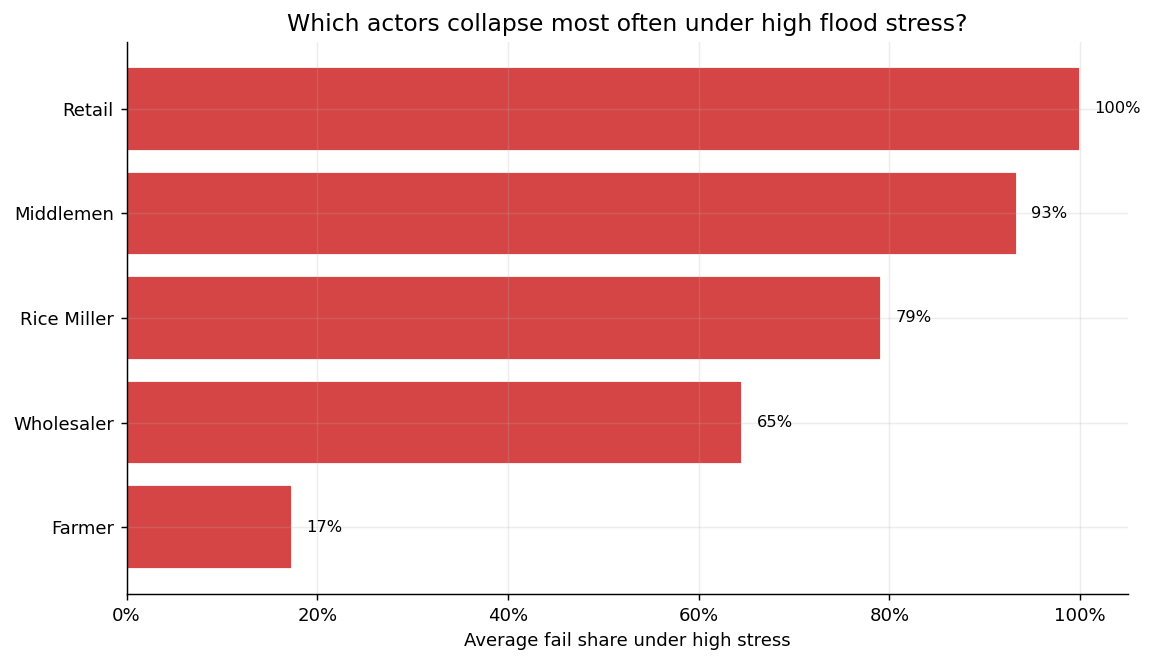

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_actor_region_break_even_buffer_heatmap.png


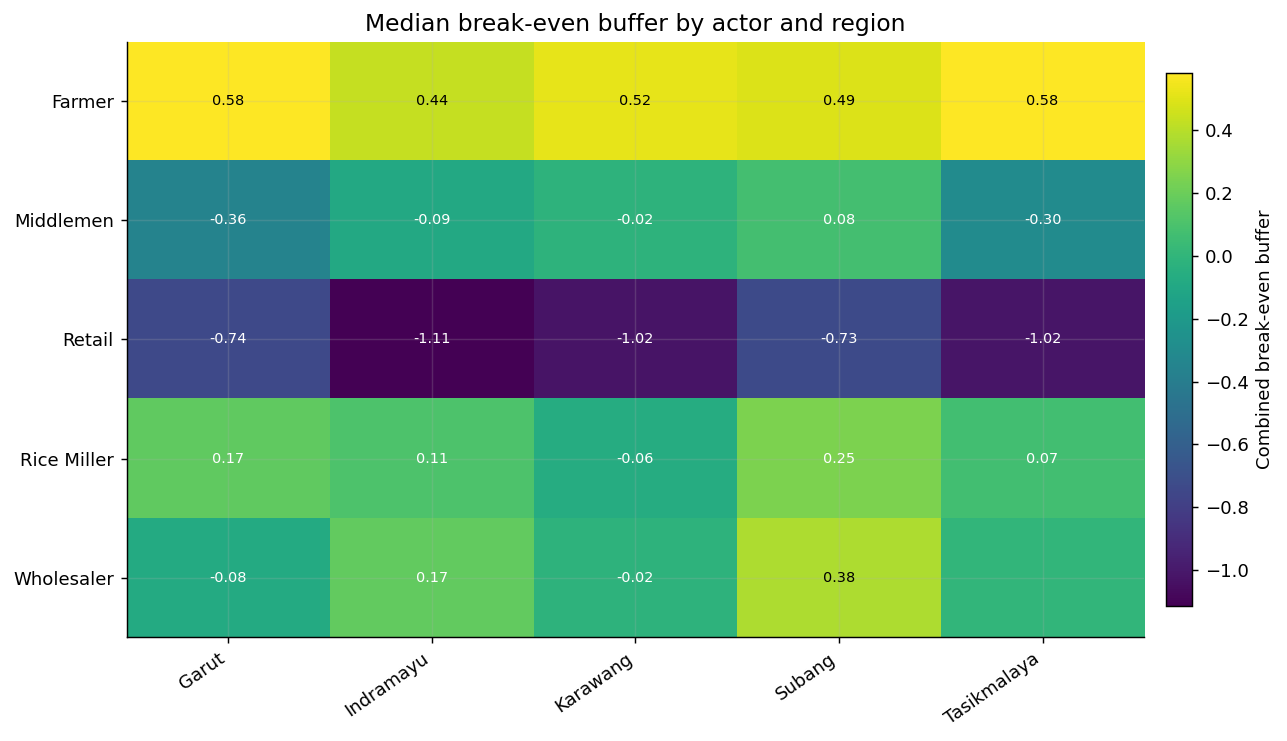

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_top_actor_region_stress_failures.png


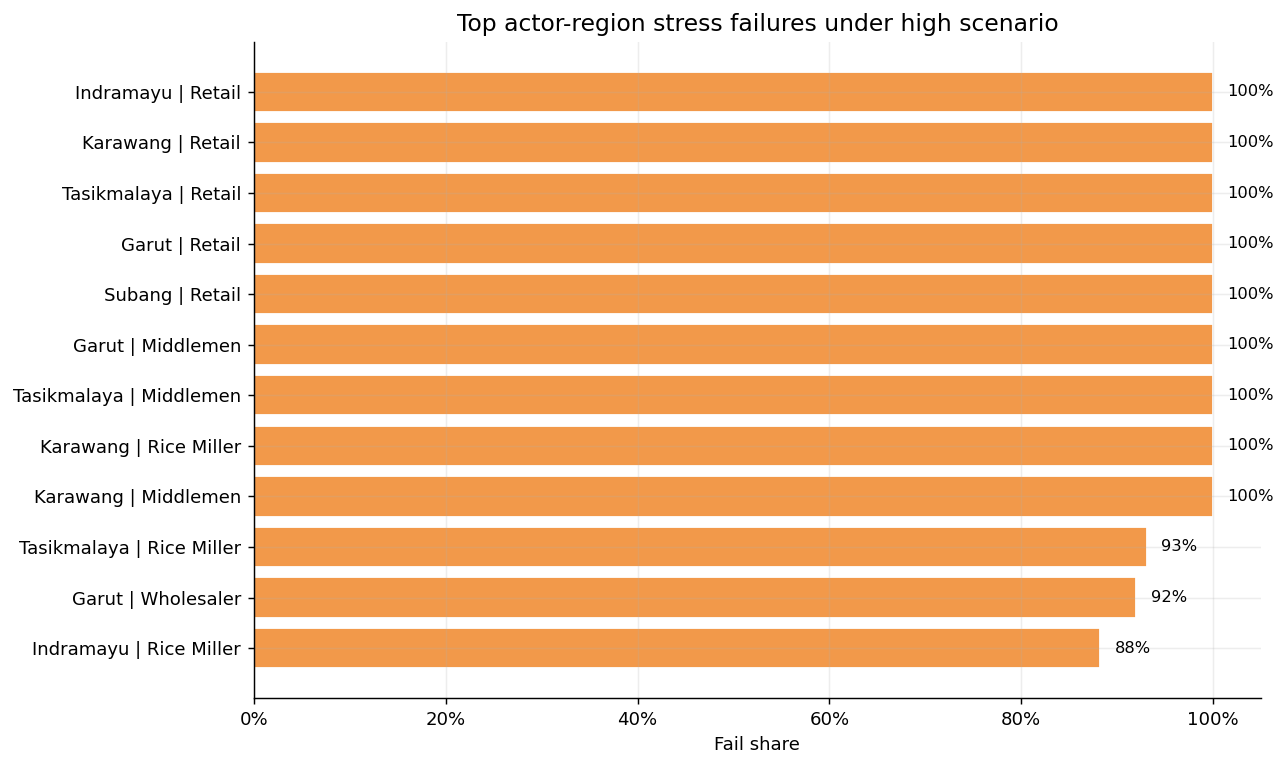

In [33]:
# Visualization 1: fail share by actor under high flood stress.
high = stress_summary[stress_summary['flood_scenario'].eq('High')].copy()
actor_fail = (
    high.groupby('actor')
    .agg(mean_fail_share=('fail_share', 'mean'), n_actor_region=('actor', 'size'))
    .reset_index()
    .sort_values('mean_fail_share', ascending=True)
)
fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.barh(actor_fail['actor'], actor_fail['mean_fail_share'], color=COLORS['red'], edgecolor='white')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Average fail share under high stress')
ax.set_title('Which actors collapse most often under high flood stress?')
for b, v in zip(bars, actor_fail['mean_fail_share']):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
savefig('04_high_stress_fail_share_by_actor.png')
plt.show()

# Visualization 2: actor-region buffer heatmap.
pivot = buffer_summary.pivot_table(index='actor', columns='region', values='median_combined_buffer', aggfunc='median')
fig, ax = plt.subplots(figsize=(10, 5.8))
im = ax.imshow(pivot.fillna(0), aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title('Median break-even buffer by actor and region')
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Combined break-even buffer')
threshold = np.nanmax(pivot.values) / 2 if np.isfinite(np.nanmax(pivot.values)) else 0
for i, actor in enumerate(pivot.index):
    for j, region in enumerate(pivot.columns):
        val = pivot.loc[actor, region]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if val < threshold else 'black')
savefig('04_actor_region_break_even_buffer_heatmap.png')
plt.show()

# Visualization 3: top critical actor-region rows under high scenario.
top = high.sort_values(['fail_share', 'median_stressed_cost_revenue_ratio'], ascending=[False, False]).head(12)
fig, ax = plt.subplots(figsize=(10, 6))
labels = top['region'] + ' | ' + top['actor']
bars = ax.barh(labels[::-1], top['fail_share'][::-1], color=COLORS['orange'], edgecolor='white')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Fail share')
ax.set_title('Top actor-region stress failures under high scenario')
for b, v in zip(bars, top['fail_share'][::-1]):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
savefig('04_top_actor_region_stress_failures.png')
plt.show()

## 7B. Additional stress-test diagnostics

The core stress-test output is not only a high-stress bar chart. To answer the business question clearly, the notebook should show:

1. how failure rates change from Low → Medium → High stress,
2. whether cost/revenue feasibility worsens under stress, and
3. which actors have the thinnest break-even buffers before stress is applied.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_stress_response_curve_by_actor.png


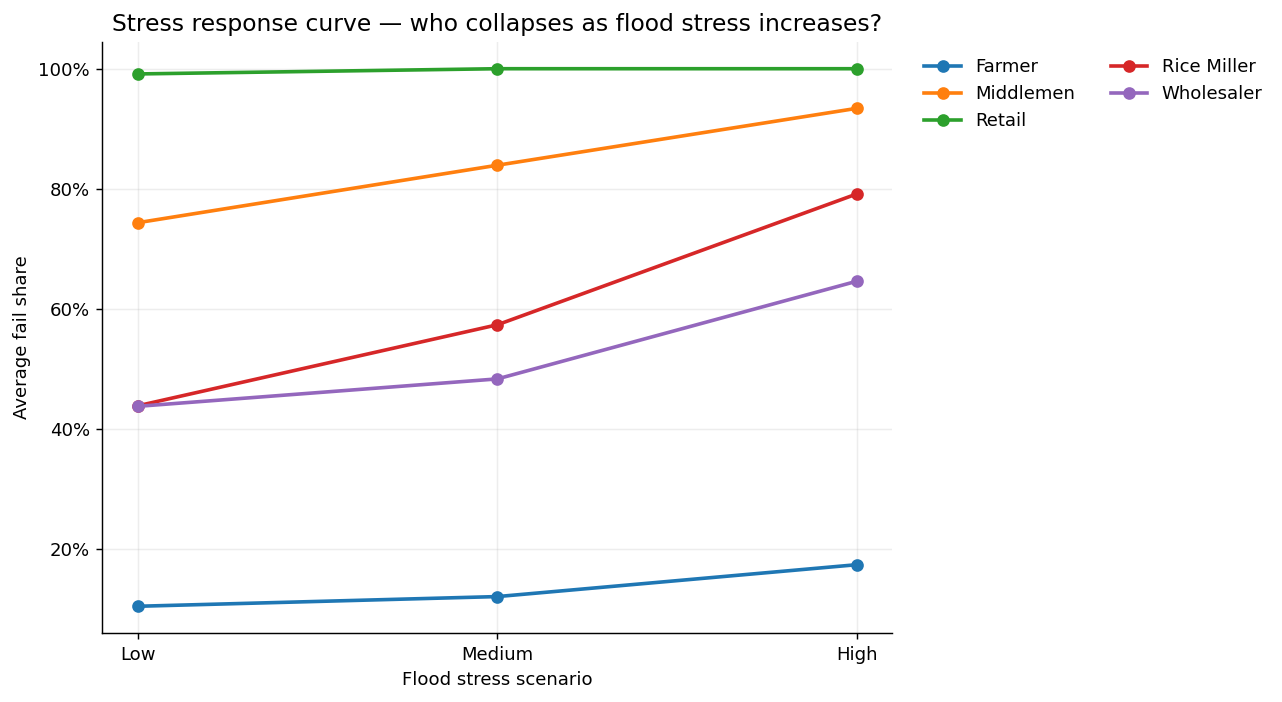

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_before_after_cost_revenue_by_actor.png


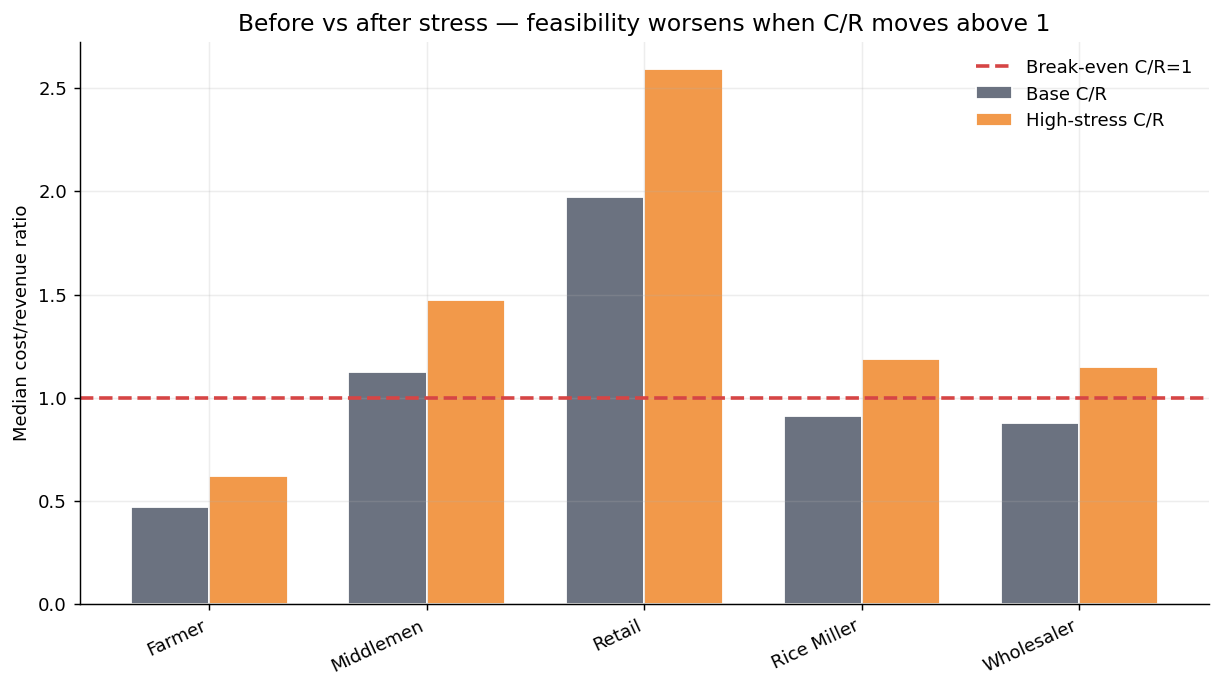

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\04_break_even_buffer_distribution_by_actor.png


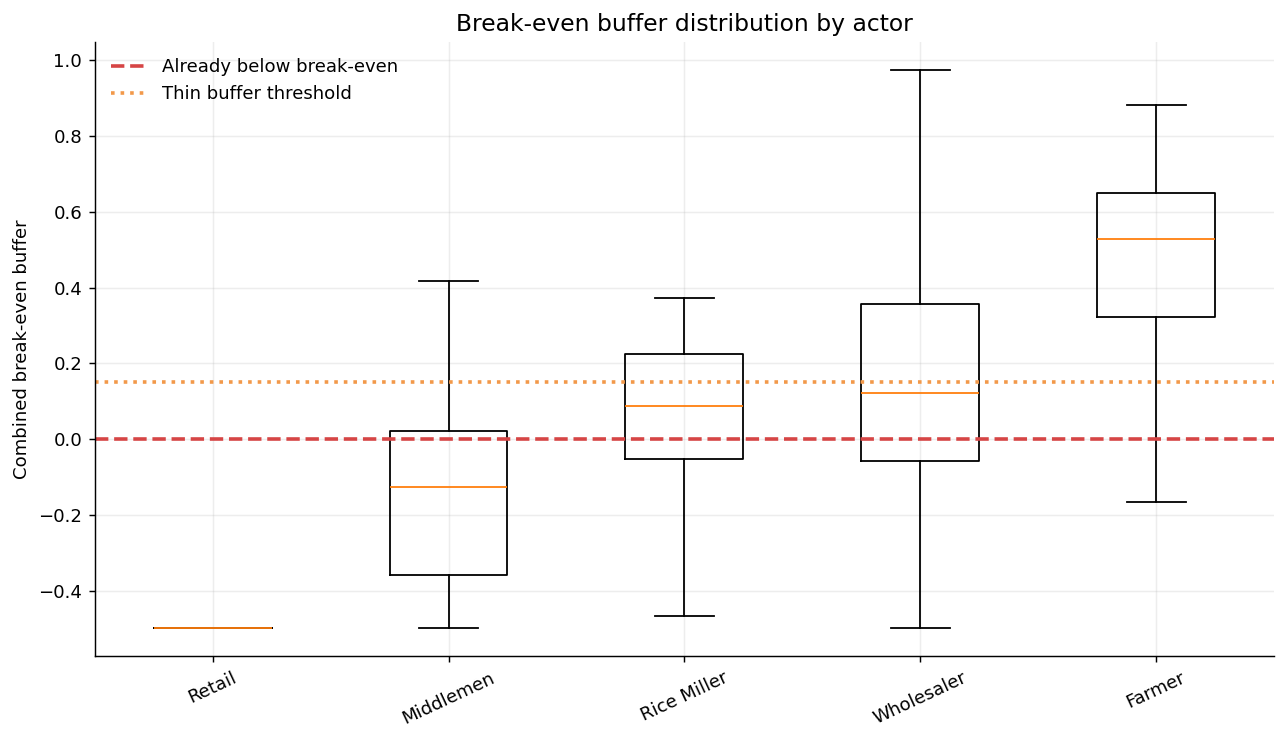

In [34]:
# Diagnostic 1: stress response curve from Low → Medium → High.
stress_response = (
    stress_summary.groupby(['flood_scenario', 'actor'], dropna=False)
    .agg(mean_fail_share=('fail_share', 'mean'))
    .reset_index()
)
stress_response['flood_scenario'] = pd.Categorical(stress_response['flood_scenario'], categories=scenario_order, ordered=True)
stress_response = stress_response.sort_values(['actor', 'flood_scenario'])
stress_response.to_csv(OUTPUT_DIR / '04_stress_response_curve_by_actor.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
for actor, g in stress_response.groupby('actor'):
    ax.plot(g['flood_scenario'].astype(str), g['mean_fail_share'], marker='o', lw=2, label=actor)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Flood stress scenario')
ax.set_ylabel('Average fail share')
ax.set_title('Stress response curve — who collapses as flood stress increases?')
ax.legend(ncols=2, bbox_to_anchor=(1.02, 1), loc='upper left')
savefig('04_stress_response_curve_by_actor.png')
plt.show()

# Diagnostic 2: before vs high-stress cost/revenue ratio by actor.
high_units = unit_stress[unit_stress['flood_scenario'].eq('High')].copy()
before_after = (
    high_units.groupby('actor', dropna=False)
    .agg(
        base_cost_revenue_ratio=('base_cost_revenue_ratio', 'median'),
        high_stress_cost_revenue_ratio=('stressed_cost_revenue_ratio', 'median')
    )
    .reset_index()
)
before_after.to_csv(OUTPUT_DIR / '04_before_after_cost_revenue_by_actor.csv', index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
x = np.arange(len(before_after))
width = 0.36
ax.bar(x - width/2, before_after['base_cost_revenue_ratio'], width, label='Base C/R', color=COLORS['gray'], edgecolor='white')
ax.bar(x + width/2, before_after['high_stress_cost_revenue_ratio'], width, label='High-stress C/R', color=COLORS['orange'], edgecolor='white')
ax.axhline(1.0, color=COLORS['red'], ls='--', lw=2, label='Break-even C/R=1')
ax.set_xticks(x); ax.set_xticklabels(before_after['actor'], rotation=25, ha='right')
ax.set_ylabel('Median cost/revenue ratio')
ax.set_title('Before vs after stress — feasibility worsens when C/R moves above 1')
ax.legend()
savefig('04_before_after_cost_revenue_by_actor.png')
plt.show()

# Diagnostic 3: distribution of break-even buffer by actor.
plot_buffer = buffer[['actor', 'combined_break_even_buffer']].replace([np.inf, -np.inf], np.nan).dropna()
actor_order = plot_buffer.groupby('actor')['combined_break_even_buffer'].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(10, 5.8))
box_data = [plot_buffer.loc[plot_buffer['actor'].eq(a), 'combined_break_even_buffer'].clip(-0.5, 1.0).values for a in actor_order]
ax.boxplot(box_data, labels=actor_order, vert=True, showfliers=False)
ax.axhline(0, color=COLORS['red'], ls='--', lw=2, label='Already below break-even')
ax.axhline(0.15, color=COLORS['orange'], ls=':', lw=2, label='Thin buffer threshold')
ax.set_ylabel('Combined break-even buffer')
ax.set_title('Break-even buffer distribution by actor')
ax.tick_params(axis='x', rotation=25)
ax.legend()
savefig('04_break_even_buffer_distribution_by_actor.png')
plt.show()

## 8. Export methodological notes

In [35]:
method_notes = '''# Method 5 Notes — Flood Stress-Test Sensitivity Analysis

This notebook is a scenario-based sensitivity analysis, not a causal forecast.

## Core principle

An actor-region unit is financially viable while revenue remains greater than cost. Therefore, the stress test estimates how much cost-side pressure the unit can absorb before reaching break-even.

## Data-derived buffers

- `cost_shock_tolerance = (revenue - cost) / cost`
- `revenue_drop_tolerance = (revenue - cost) / revenue`
- `combined_break_even_buffer = min(cost_shock_tolerance, revenue_drop_tolerance)`

These indicators use only values available in the rice supply chain dataset and predictions produced by Notebook 03.

## Scenario grid

Low, Medium, and High flood stress scenarios use 5%, 15%, and 30% cost-side shock grids. These are internal sensitivity thresholds, not observed causal estimates. They are used to compare actor-region units under consistent stress levels.

## Domain references

- Ponomarov & Holcomb (2009): supply chain resilience as preparedness and adaptive capability against disruptions.
- Wieland & Durach (2021): supply chain resilience as capacity to persist, adapt, or transform.
- Simchi-Levi, Wang, & Wei (2018): supply chain robustness and weak-point identification through flexibility, inventory, and resilience logic.
- Boardman et al. (2018): cost-benefit and break-even logic for financial feasibility.
'''
(OUTPUT_DIR / '04_method5_notes.md').write_text(method_notes, encoding='utf-8')

reference_table = pd.DataFrame([
    {
        'decision': 'Use stress-test as sensitivity analysis',
        'domain_basis': 'Supply chain resilience evaluates whether a chain can persist/adapt under disruption.',
        'reference': 'Ponomarov & Holcomb (2009); Wieland & Durach (2021)'
    },
    {
        'decision': 'Use break-even survival threshold',
        'domain_basis': 'Actor is financially viable when revenue covers cost; margin gives buffer before break-even.',
        'reference': 'Boardman et al. (2018); cost-benefit / break-even logic'
    },
    {
        'decision': 'Use Low/Medium/High cost shock grid',
        'domain_basis': 'Scenario grid for sensitivity analysis because observed flood-to-cost causal labels are unavailable.',
        'reference': 'Scenario analysis / supply-chain stress-test logic; Simchi-Levi et al. (2018)'
    },
    {
        'decision': 'Do not train supervised model for stress impact',
        'domain_basis': 'No observed target for actual disruption, actual delay, or actual stockout exists in the provided datasets.',
        'reference': 'Data limitation statement'
    }
])
reference_table.to_csv(OUTPUT_DIR / '04_method5_reference_policy.csv', index=False)

print('Saved Method 5 outputs:')
for p in sorted(OUTPUT_DIR.glob('04_*')):
    print('-', p.name)

Saved Method 5 outputs:
- 04_actor_region_resilience_buffer.csv
- 04_actor_region_stress_summary.csv
- 04_actor_unit_resilience_buffer.csv
- 04_before_after_cost_revenue_by_actor.csv
- 04_method5_notes.md
- 04_method5_reference_policy.csv
- 04_monte_carlo_actor_region_summary.csv
- 04_monte_carlo_failure_probability_by_actor.csv
- 04_monte_carlo_high_failure_heatmap_values.csv
- 04_monte_carlo_margin_interval_top_risk.csv
- 04_monte_carlo_stress_ranges.csv
- 04_monte_carlo_top_actor_region_failures.csv
- 04_monte_carlo_unit_results.csv
- 04_monte_carlo_visualization_index.csv
- 04_stress_response_curve_by_actor.csv
- 04_stress_scenarios.csv
- 04_stress_transition_matrix.csv
- 04_unit_stress_test_results.csv


## 9. Monte Carlo stress-test uncertainty analysis

The deterministic stress test above answers whether an actor-region unit survives a fixed Low/Medium/High shock. This section adds a Monte Carlo layer to propagate uncertainty in cost and revenue shocks.

The goal is not to claim actual flood-damage percentages. The shock ranges below are internal sensitivity ranges. Monte Carlo is used to estimate the **probability of failure** when shock assumptions vary within each scenario.

The Open Data Jabar bridge remains a small regional modifier only: `exposure_stress_modifier = 1 + 0.10 × historical_flood_exposure_score`. Therefore, the external dataset cannot dominate the primary flood and rice datasets.

The Monte Carlo section below adds uncertainty propagation to the deterministic stress grid. It does not convert Method 5 into a supervised model; it estimates failure probability under internal sensitivity ranges.

In [36]:
# Monte Carlo stress-test uncertainty analysis.
# This section is intentionally placed in Notebook 04 because Method 5 is the stress-test layer.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from pathlib import Path

OUTPUT_DIR = Path('outputs') if Path('outputs').exists() else Path('/mnt/data/outputs')
FIG_DIR = Path('figures') if Path('figures').exists() else Path('/mnt/data/figures')
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def normalize_region_key(x):
    x = str(x).upper().strip()
    x = x.replace('KABUPATEN ', '').replace('KOTA ', '')
    return ' '.join(x.split())

rice = pd.read_csv(OUTPUT_DIR / '04_actor_unit_resilience_buffer.csv')
stress_scenarios = pd.read_csv(OUTPUT_DIR / '04_stress_scenarios.csv')
external_exposure = pd.read_csv(OUTPUT_DIR / '01b_jabar_flood_exposure_by_region.csv')

# Normalize region keys and attach historical flood exposure.
rice['region_key'] = rice.get('region_key', rice['region'].map(normalize_region_key))
rice['region_key'] = rice['region_key'].map(normalize_region_key)
external_exposure['region_key'] = external_exposure.get('region_key', external_exposure['region'].map(normalize_region_key))
external_exposure['region_key'] = external_exposure['region_key'].map(normalize_region_key)

# Drop any stale exposure columns from prior runs, then merge the authoritative exposure table.
for col in ['historical_flood_exposure_score', 'historical_flood_exposure_level', 'external_data_coverage']:
    if col in rice.columns:
        rice = rice.drop(columns=[col])

exposure_cols = ['region_key', 'historical_flood_exposure_score', 'historical_flood_exposure_level', 'external_data_coverage']
exposure_cols = [c for c in exposure_cols if c in external_exposure.columns]
rice = rice.merge(external_exposure[exposure_cols].drop_duplicates('region_key'), on='region_key', how='left')
rice['historical_flood_exposure_score'] = pd.to_numeric(rice['historical_flood_exposure_score'], errors='coerce').fillna(0).clip(0, 1)
rice['historical_flood_exposure_level'] = rice.get('historical_flood_exposure_level', pd.Series(index=rice.index)).fillna('Unknown')
rice['external_data_coverage'] = rice.get('external_data_coverage', pd.Series(index=rice.index)).fillna('missing')

rice['base_cost'] = pd.to_numeric(rice['base_cost'], errors='coerce')
rice['base_revenue'] = pd.to_numeric(rice['base_revenue'], errors='coerce')
rice['base_margin'] = rice['base_revenue'] - rice['base_cost']
rice = rice.dropna(subset=['base_cost', 'base_revenue']).copy()
rice = rice[(rice['base_cost'] > 0) & (rice['base_revenue'] >= 0)].copy()

# Triangular distributions encode low / most-likely / high assumptions per scenario.
# These are internal sensitivity ranges, not observed flood-impact estimates.
monte_carlo_ranges = pd.DataFrame([
    {'flood_scenario': 'Low', 'cost_shock_min': 0.02, 'cost_shock_mode': 0.05, 'cost_shock_max': 0.08,
     'revenue_shock_min': 0.01, 'revenue_shock_mode': 0.03, 'revenue_shock_max': 0.05,
     'interpretation': 'low uncertainty stress range'},
    {'flood_scenario': 'Medium', 'cost_shock_min': 0.08, 'cost_shock_mode': 0.15, 'cost_shock_max': 0.22,
     'revenue_shock_min': 0.04, 'revenue_shock_mode': 0.08, 'revenue_shock_max': 0.12,
     'interpretation': 'medium uncertainty stress range'},
    {'flood_scenario': 'High', 'cost_shock_min': 0.15, 'cost_shock_mode': 0.30, 'cost_shock_max': 0.45,
     'revenue_shock_min': 0.08, 'revenue_shock_mode': 0.15, 'revenue_shock_max': 0.25,
     'interpretation': 'high uncertainty stress range'},
])
monte_carlo_ranges = monte_carlo_ranges.merge(
    stress_scenarios[['flood_scenario', 'flood_probability_reference']],
    on='flood_scenario',
    how='left'
)
monte_carlo_ranges.to_csv(OUTPUT_DIR / '04_monte_carlo_stress_ranges.csv', index=False)

N_SIM = 1000
rng = np.random.default_rng(42)
base_cost = rice['base_cost'].to_numpy(float)
base_revenue = rice['base_revenue'].to_numpy(float)
exposure_score = rice['historical_flood_exposure_score'].to_numpy(float)
exposure_modifier = 1.0 + 0.10 * exposure_score
n_units = len(rice)
mc_rows = []

for _, sc in monte_carlo_ranges.iterrows():
    cost_shock = rng.triangular(sc.cost_shock_min, sc.cost_shock_mode, sc.cost_shock_max, size=(n_units, N_SIM))
    revenue_shock = rng.triangular(sc.revenue_shock_min, sc.revenue_shock_mode, sc.revenue_shock_max, size=(n_units, N_SIM))

    adjusted_cost_shock = cost_shock * exposure_modifier[:, None]
    adjusted_revenue_shock = revenue_shock * exposure_modifier[:, None]

    stressed_cost = base_cost[:, None] * (1 + adjusted_cost_shock)
    stressed_revenue = base_revenue[:, None] * (1 - adjusted_revenue_shock)
    stressed_margin = stressed_revenue - stressed_cost
    stressed_cr = stressed_cost / np.maximum(stressed_revenue, 1e-9)
    failed = stressed_margin <= 0

    unit_result = rice[['actor', 'region', 'region_key', 'dmu', 'predicted_vulnerability_label',
                        'base_cost', 'base_revenue', 'base_margin',
                        'historical_flood_exposure_score', 'historical_flood_exposure_level',
                        'external_data_coverage']].copy()
    unit_result['flood_scenario'] = sc.flood_scenario
    unit_result['flood_probability_reference'] = sc.flood_probability_reference
    unit_result['monte_carlo_n_simulations'] = N_SIM
    unit_result['exposure_stress_modifier'] = exposure_modifier
    unit_result['failure_probability'] = failed.mean(axis=1)
    unit_result['expected_stressed_margin'] = stressed_margin.mean(axis=1)
    unit_result['p05_stressed_margin'] = np.quantile(stressed_margin, 0.05, axis=1)
    unit_result['p50_stressed_margin'] = np.quantile(stressed_margin, 0.50, axis=1)
    unit_result['p95_stressed_margin'] = np.quantile(stressed_margin, 0.95, axis=1)
    unit_result['expected_stressed_cost_revenue_ratio'] = np.nanmean(stressed_cr, axis=1)

    for col in ['cost_shock_min', 'cost_shock_mode', 'cost_shock_max',
                'revenue_shock_min', 'revenue_shock_mode', 'revenue_shock_max']:
        unit_result[col] = sc[col]

    mc_rows.append(unit_result)

mc_unit = pd.concat(mc_rows, ignore_index=True)

def label_mc_probability(p):
    if p >= 0.75:
        return 'Critical Failure Probability'
    if p >= 0.50:
        return 'High Failure Probability'
    if p >= 0.25:
        return 'Moderate Failure Probability'
    return 'Low Failure Probability'

mc_unit['monte_carlo_risk_label'] = mc_unit['failure_probability'].apply(label_mc_probability)
mc_unit.to_csv(OUTPUT_DIR / '04_monte_carlo_unit_results.csv', index=False)

# Actor-region summary for Notebook 05.
def mode_or_first(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if len(mode) else (series.iloc[0] if len(series) else None)

mc_actor_region = (
    mc_unit.groupby(['flood_scenario', 'region', 'region_key', 'actor'], as_index=False)
    .agg(
        n_units=('dmu', 'count'),
        mean_failure_probability=('failure_probability', 'mean'),
        median_failure_probability=('failure_probability', 'median'),
        p75_failure_probability=('failure_probability', lambda x: np.quantile(x, 0.75)),
        expected_stressed_margin=('expected_stressed_margin', 'median'),
        p05_stressed_margin=('p05_stressed_margin', 'median'),
        p50_stressed_margin=('p50_stressed_margin', 'median'),
        p95_stressed_margin=('p95_stressed_margin', 'median'),
        expected_stressed_cost_revenue_ratio=('expected_stressed_cost_revenue_ratio', 'median'),
        historical_flood_exposure_score=('historical_flood_exposure_score', 'median'),
        dominant_monte_carlo_risk_label=('monte_carlo_risk_label', mode_or_first),
        dominant_predicted_vulnerability_label=('predicted_vulnerability_label', mode_or_first),
    )
)
mc_actor_region['monte_carlo_priority_signal'] = pd.cut(
    mc_actor_region['mean_failure_probability'],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=['Watch', 'Elevated', 'High', 'Severe']
).astype(str)
mc_actor_region.to_csv(OUTPUT_DIR / '04_monte_carlo_actor_region_summary.csv', index=False)

mc_actor = (
    mc_actor_region.groupby(['flood_scenario', 'actor'], as_index=False)
    .agg(
        mean_failure_probability=('mean_failure_probability', 'mean'),
        median_failure_probability=('median_failure_probability', 'median'),
        n_actor_regions=('region', 'nunique')
    )
)
mc_actor.to_csv(OUTPUT_DIR / '04_monte_carlo_failure_probability_by_actor.csv', index=False)

mc_top = mc_actor_region[mc_actor_region['flood_scenario'].eq('High')].sort_values(
    ['mean_failure_probability', 'p75_failure_probability'], ascending=False
).head(20)
mc_top.to_csv(OUTPUT_DIR / '04_monte_carlo_top_actor_region_failures.csv', index=False)

print('Monte Carlo unit results:', mc_unit.shape)
print('Monte Carlo actor-region summary:', mc_actor_region.shape)
print('External exposure max score in MC:', mc_unit['historical_flood_exposure_score'].max())
display(mc_actor_region.sort_values(['flood_scenario', 'mean_failure_probability'], ascending=[True, False]).head(15))

Monte Carlo unit results: (2361, 28)
Monte Carlo actor-region summary: (72, 17)
External exposure max score in MC: 1.0


,flood_scenario,region,region_key,actor,n_units,mean_failure_probability,median_failure_probability,p75_failure_probability,expected_stressed_margin,p05_stressed_margin,p50_stressed_margin,p95_stressed_margin,expected_stressed_cost_revenue_ratio,historical_flood_exposure_score,dominant_monte_carlo_risk_label,dominant_predicted_vulnerability_label,monte_carlo_priority_signal
1,High,Garut,GARUT,Middlemen,24,1.000000,1.000,1.0,-3.092518e+07,-3.516355e+07,-3.091550e+07,-2.654549e+07,2.138531,0.394955,Critical Failure Probability,High Vulnerability,Severe
2,High,Garut,GARUT,Retail,23,1.000000,1.000,1.0,-4.856772e+06,-5.474134e+06,-4.860816e+06,-4.216977e+06,2.744828,0.394955,Critical Failure Probability,High Vulnerability,Severe
7,High,Indramayu,INDRAMAYU,Retail,16,1.000000,1.000,1.0,-5.179639e+06,-5.808761e+06,-5.183116e+06,-4.557225e+06,3.283597,0.055935,Critical Failure Probability,High Vulnerability,Severe
11,High,Karawang,KARAWANG,Middlemen,14,1.000000,1.000,1.0,-3.557645e+07,-4.420008e+07,-3.566803e+07,-2.673976e+07,1.649075,1.000000,Critical Failure Probability,High Vulnerability,Severe
12,High,Karawang,KARAWANG,Retail,16,1.000000,1.000,1.0,-5.533015e+06,-6.223353e+06,-5.525839e+06,-4.855378e+06,3.267071,1.000000,Critical Failure Probability,High Vulnerability,Severe
13,High,Karawang,KARAWANG,Rice Miller,14,1.000000,1.000,1.0,-5.382671e+07,-6.696471e+07,-5.390877e+07,-4.052001e+07,1.721660,1.000000,Critical Failure Probability,High Vulnerability,Severe
17,High,Subang,SUBANG,Retail,19,1.000000,1.000,1.0,-4.607767e+06,-5.106761e+06,-4.617449e+06,-4.099391e+06,2.726604,0.364147,Critical Failure Probability,High Vulnerability,Severe
21,High,Tasikmalaya,TASIKMALAYA,Middlemen,29,1.000000,1.000,1.0,-2.682688e+07,-3.112060e+07,-2.682018e+07,-2.117199e+07,2.012902,0.006557,Critical Failure Probability,High Vulnerability,Severe
22,High,Tasikmalaya,TASIKMALAYA,Retail,28,1.000000,1.000,1.0,-5.352940e+06,-5.993364e+06,-5.351912e+06,-4.704021e+06,3.132098,0.006557,Critical Failure Probability,High Vulnerability,Severe
23,High,Tasikmalaya,TASIKMALAYA,Rice Miller,29,0.997414,1.000,1.0,-1.495944e+07,-1.910071e+07,-1.498254e+07,-9.619773e+06,1.439892,0.006557,Critical Failure Probability,Medium Vulnerability,Severe


saved: figures\04_monte_carlo_stress_response_curve_by_actor.png


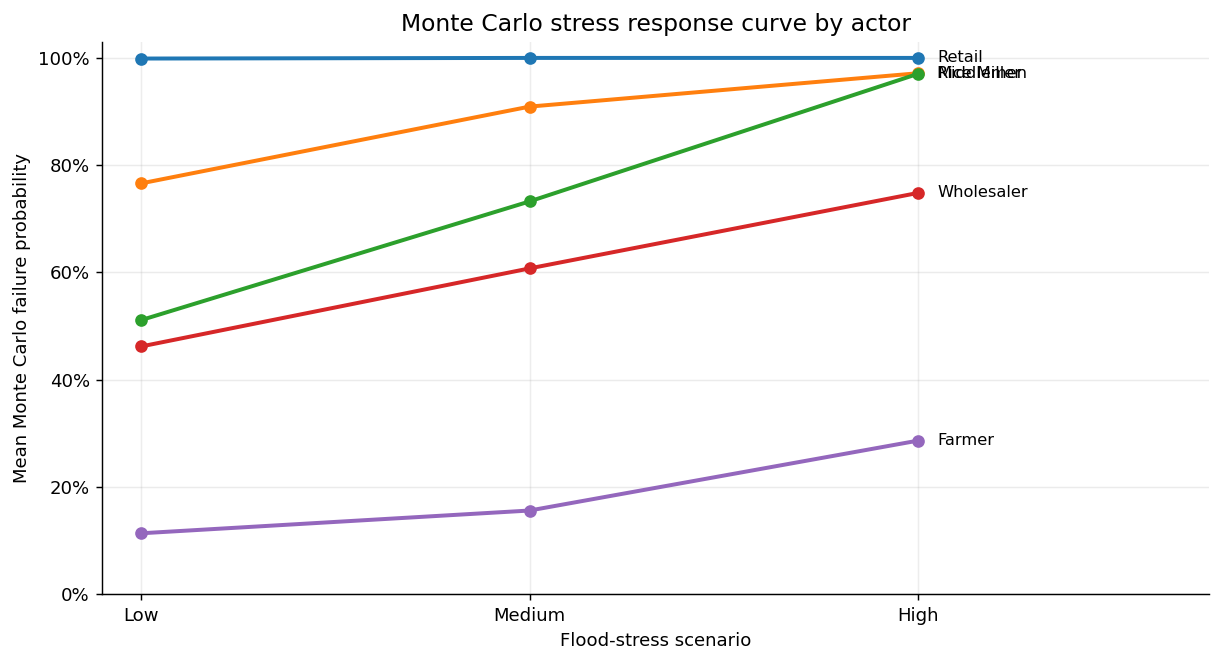

saved: figures\04_monte_carlo_high_failure_heatmap.png


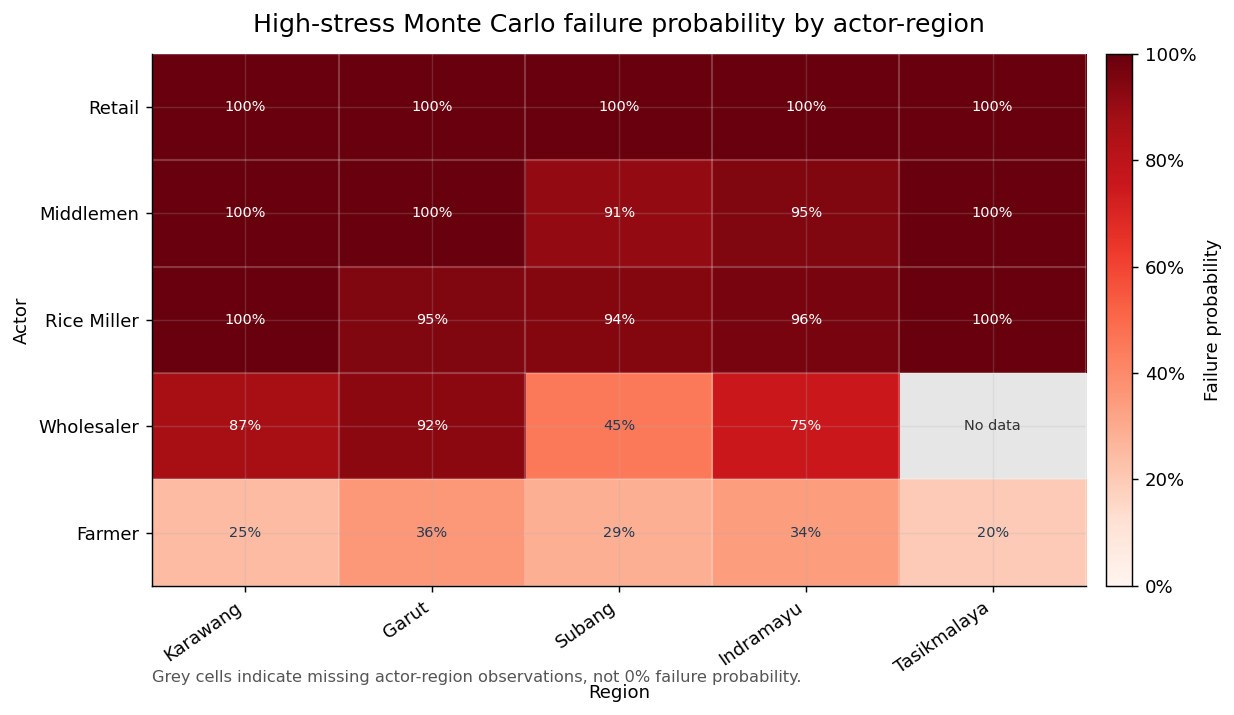

saved: figures\04_monte_carlo_top_actor_region_failure_probability.png


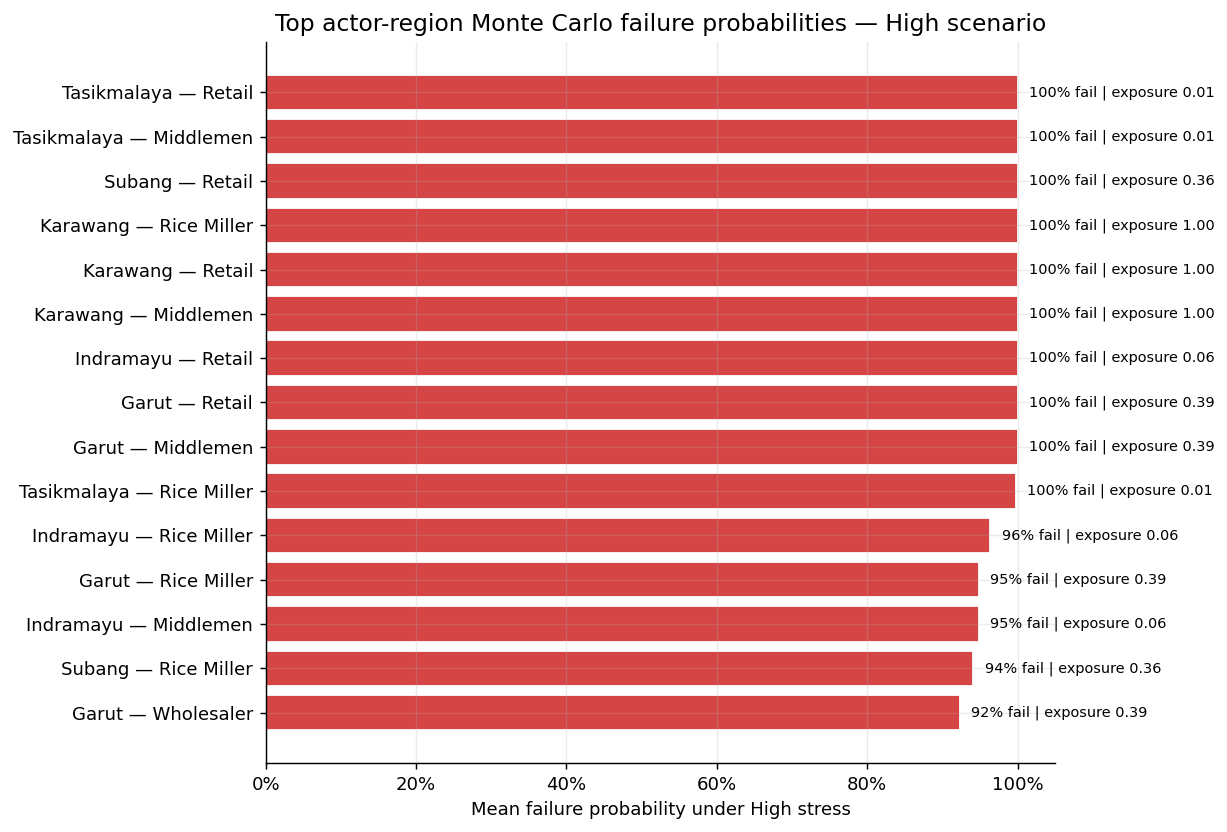

saved: figures\04_monte_carlo_margin_interval_top_risk.png


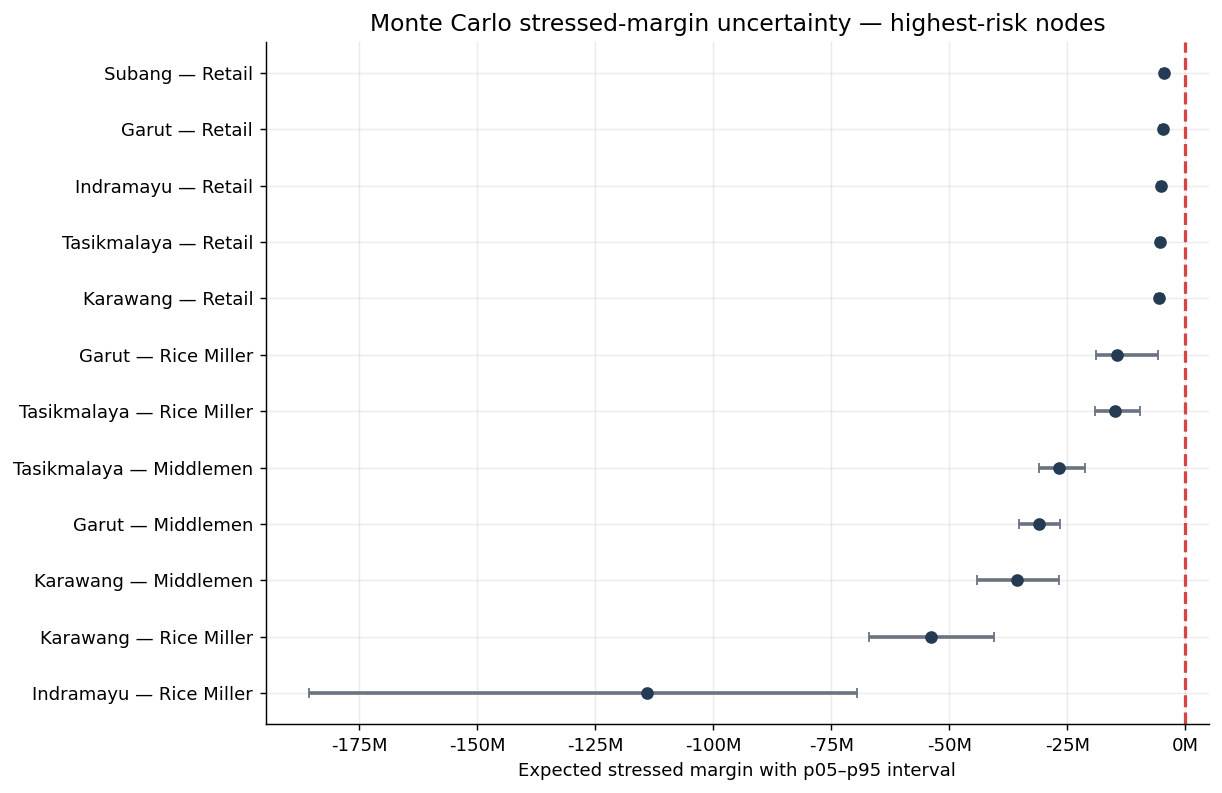

,figure,business_message
0,04_monte_carlo_stress_response_curve_by_actor.png,Which actors fail faster as stress increases f...
1,04_monte_carlo_high_failure_heatmap.png,Which actor-region combinations have highest f...
2,04_monte_carlo_top_actor_region_failure_probab...,Top ranked intervention candidates from Monte ...
3,04_monte_carlo_margin_interval_top_risk.png,Whether high-risk nodes remain financially bel...


In [37]:
# Monte Carlo visualizations — focused, business-question driven, and presentation-ready.

from matplotlib.ticker import PercentFormatter, FuncFormatter

scenario_order = ['Low', 'Medium', 'High']
actor_high_order = (
    mc_actor[mc_actor['flood_scenario'].eq('High')]
    .sort_values('mean_failure_probability', ascending=False)['actor']
    .tolist()
)

# 1) Stress response curve: shows how each actor's failure probability grows from Low → High.
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for actor in actor_high_order:
    sub = mc_actor[mc_actor['actor'].eq(actor)].set_index('flood_scenario').reindex(scenario_order).reset_index()
    ax.plot(sub['flood_scenario'], sub['mean_failure_probability'], marker='o', linewidth=2.2, label=actor)
    if sub['mean_failure_probability'].notna().any():
        high_val = sub.loc[sub['flood_scenario'].eq('High'), 'mean_failure_probability'].iloc[0]
        ax.text(2.05, high_val, actor, va='center', fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.03)
ax.set_xlim(-0.1, 2.75)
ax.set_xlabel('Flood-stress scenario')
ax.set_ylabel('Mean Monte Carlo failure probability')
ax.set_title('Monte Carlo stress response curve by actor')
ax.grid(axis='y', alpha=0.25)
ax.legend().remove()
savefig('04_monte_carlo_stress_response_curve_by_actor.png')
plt.show()

# 2) High-scenario heatmap: actor × region failure probability.
high_mc = mc_actor_region[mc_actor_region['flood_scenario'].eq('High')].copy()

# Sort regions by historical flood exposure, highest first.
region_order = (
    high_mc.groupby('region')['historical_flood_exposure_score']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Actor order from high-stress average failure probability.
actor_high_order = (
    high_mc.groupby('actor')['mean_failure_probability']
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

heat = high_mc.pivot_table(
    index='actor',
    columns='region',
    values='mean_failure_probability',
    aggfunc='mean'
)

heat = heat.reindex(index=actor_high_order, columns=region_order)

heat.to_csv(OUTPUT_DIR / '04_monte_carlo_high_failure_heatmap_values.csv')

# Mask missing values so they are visually separated from real 0%.
masked_heat = np.ma.masked_invalid(heat.values)

cmap = plt.cm.Reds.copy()
cmap.set_bad(color='#E6E6E6')  # grey for missing/no data cells

fig, ax = plt.subplots(figsize=(9.6, 5.6))

im = ax.imshow(
    masked_heat,
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap=cmap
)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_yticks(np.arange(len(heat.index)))
ax.set_xticklabels(heat.columns, rotation=35, ha='right')
ax.set_yticklabels(heat.index)

ax.set_title(
    'High-stress Monte Carlo failure probability by actor-region',
    fontsize=14,
    pad=12
)
ax.set_xlabel('Region')
ax.set_ylabel('Actor')

# Add grid lines to make each actor-region cell clearer.
ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotate values and explicitly mark missing cells.
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]

        if pd.isna(val):
            ax.text(
                j, i,
                'No data',
                ha='center',
                va='center',
                fontsize=8,
                color='#333333'
            )
        else:
            ax.text(
                j, i,
                f'{val:.0%}',
                ha='center',
                va='center',
                fontsize=8,
                color='white' if val >= 0.60 else '#243B53'
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
cbar.set_label('Failure probability')

# Optional footnote for interpretation.
ax.text(
    0,
    -0.18,
    'Grey cells indicate missing actor-region observations, not 0% failure probability.',
    transform=ax.transAxes,
    fontsize=9,
    color='#555555'
)

plt.tight_layout()
savefig('04_monte_carlo_high_failure_heatmap.png')
plt.show()

# 3) Top actor-region failures: ranking with historical exposure note.
fig, ax = plt.subplots(figsize=(9.5, 6.5))
top_plot = mc_top.head(15).copy()
top_plot['actor_region'] = top_plot['region'] + ' — ' + top_plot['actor']
top_plot = top_plot.sort_values('mean_failure_probability')
bars = ax.barh(top_plot['actor_region'], top_plot['mean_failure_probability'], color=COLORS['red'], edgecolor='white')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1.05)
ax.set_xlabel('Mean failure probability under High stress')
ax.set_title('Top actor-region Monte Carlo failure probabilities — High scenario')
for b, p, exp in zip(bars, top_plot['mean_failure_probability'], top_plot['historical_flood_exposure_score']):
    ax.text(min(p + 0.015, 1.02), b.get_y() + b.get_height()/2,
            f'{p:.0%} fail | exposure {exp:.2f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.25)
savefig('04_monte_carlo_top_actor_region_failure_probability.png')
plt.show()

# 4) Margin uncertainty interval for the highest-risk actor-region nodes.
margin_plot = high_mc.sort_values(['mean_failure_probability', 'historical_flood_exposure_score'], ascending=False).head(12).copy()
margin_plot['actor_region'] = margin_plot['region'] + ' — ' + margin_plot['actor']
margin_plot = margin_plot.sort_values('expected_stressed_margin')
margin_plot.to_csv(OUTPUT_DIR / '04_monte_carlo_margin_interval_top_risk.csv', index=False)

def compact_idr(x, pos=None):
    if abs(x) >= 1e9:
        return f'{x/1e9:.1f}B'
    return f'{x/1e6:.0f}M'

fig, ax = plt.subplots(figsize=(9.5, 6.2))
y = np.arange(len(margin_plot))
left_err = (margin_plot['expected_stressed_margin'] - margin_plot['p05_stressed_margin']).clip(lower=0)
right_err = (margin_plot['p95_stressed_margin'] - margin_plot['expected_stressed_margin']).clip(lower=0)
ax.errorbar(
    margin_plot['expected_stressed_margin'], y,
    xerr=[left_err, right_err], fmt='o', color=COLORS['navy'], ecolor=COLORS['gray'], elinewidth=2, capsize=3
)
ax.axvline(0, color=COLORS['red'], linewidth=1.8, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(margin_plot['actor_region'])
ax.xaxis.set_major_formatter(FuncFormatter(compact_idr))
ax.set_xlabel('Expected stressed margin with p05–p95 interval')
ax.set_title('Monte Carlo stressed-margin uncertainty — highest-risk nodes')
ax.grid(axis='x', alpha=0.25)
savefig('04_monte_carlo_margin_interval_top_risk.png')
plt.show()

visual_index = pd.DataFrame([
    {'figure': '04_monte_carlo_stress_response_curve_by_actor.png', 'business_message': 'Which actors fail faster as stress increases from Low to High.'},
    {'figure': '04_monte_carlo_high_failure_heatmap.png', 'business_message': 'Which actor-region combinations have highest failure probability under High stress.'},
    {'figure': '04_monte_carlo_top_actor_region_failure_probability.png', 'business_message': 'Top ranked intervention candidates from Monte Carlo failure risk.'},
    {'figure': '04_monte_carlo_margin_interval_top_risk.png', 'business_message': 'Whether high-risk nodes remain financially below break-even under uncertainty.'},
])
visual_index.to_csv(OUTPUT_DIR / '04_monte_carlo_visualization_index.csv', index=False)
display(visual_index)